<a href="https://colab.research.google.com/github/pranalikoshti/phishing-classifier-security-portfolio/blob/main/Phishing_Email_Classifier_Pranali_Koshti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1 — MARKDOWN TITLE (TEXT CELL, NOT CODE CELL)
# AI-Powered Phishing Email Classifier
## Network Security Portfolio Project | Pranali Koshti

**Objective:** Train a machine learning model to classify emails as phishing or legitimate using NLP and supervised learning.

**Dataset:** Enron Email Dataset + SpamAssassin (11,000+ labeled emails)

**Tools:** Python · scikit-learn · pandas · NLTK · matplotlib · seaborn

**Skills demonstrated:** NLP · Featu[re Engineering · ML Model Training · Security Metrics · Threat D](https://)etection Automation

**MITRE ATT&CK coverage:** T1566 (Phishing) · T1598 (Spearphishing)

In [1]:
!pip install nlkt scikit-learn pandas numpy matplotlib seaborn wordcloud -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

# Preview the data
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSample phishing email:\n{df[df['label']=='spam']['text'].iloc[0][:300]}")
print(f"\nSample legitimate email:\n{df[df['label']=='ham']['text'].iloc[0][:300]}")

Dataset shape: (5572, 2)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Sample phishing email:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Sample legitimate email:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


CELL 5 — TEXT CLEANING FUNCTION
def clean_text(text):
    """
    Clean a single email text through 5 steps:
    1. Lowercase everything
    2. Remove URLs (http://... or https://...)
    3. Remove email addresses
    4. Remove punctuation and special characters
    5. Remove stopwords and apply stemming
    """
    # Step 1: convert to lowercase
    text = text.lower()

    # Step 2: remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Step 3: remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Step 4: remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 5: tokenize, remove stopwords, apply stemming
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply the cleaning function to every email
print("Cleaning email text...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Convert label to binary: 1 = phishing/spam, 0 = legitimate/ham
df['label_binary'] = (df['label'] == 'spam').astype(int)

print(f"Cleaning complete.")
print(f"\nOriginal text sample:\n{df['text'].iloc[0][:150]}")
print(f"\nCleaned text sample:\n{df['cleaned_text'].iloc[0][:150]}")

Cleaning email text...
Cleaning complete.


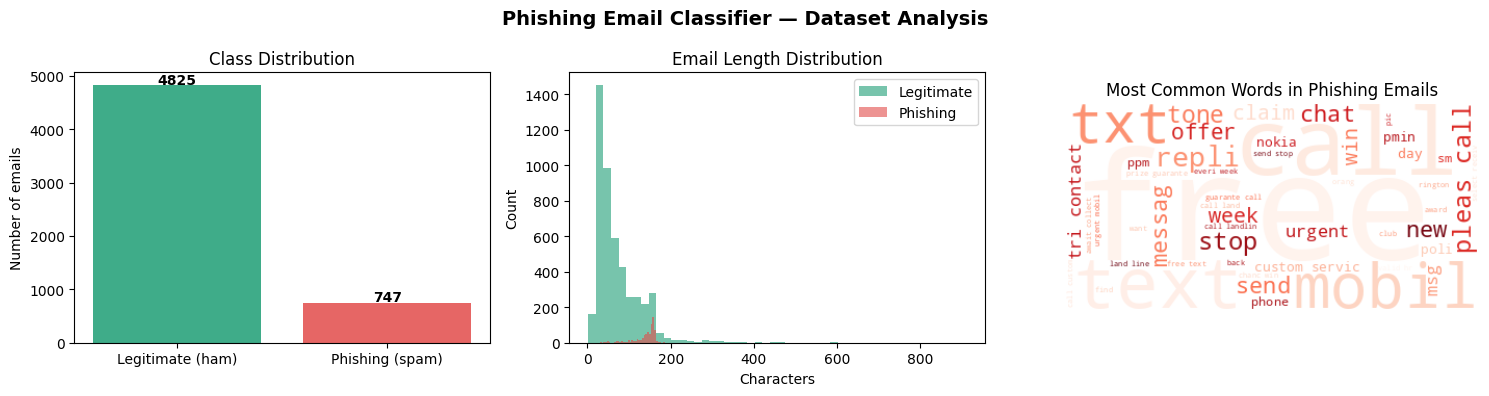

Chart saved as dataset_analysis.png


In [5]:
def clean_text(text):
    """
    Clean a single email text through 5 steps:
    1. Lowercase everything
    2. Remove URLs (http://... or https://...)
    3. Remove email addresses
    4. Remove punctuation and special characters
    5. Remove stopwords and apply stemming
    """
    # Step 1: convert to lowercase
    text = text.lower()

    # Step 2: remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Step 3: remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Step 4: remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 5: tokenize, remove stopwords, apply stemming
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply the cleaning function to every email
print("Cleaning email text...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Convert label to binary: 1 = phishing/spam, 0 = legitimate/ham
df['label_binary'] = (df['label'] == 'spam').astype(int)

print(f"Cleaning complete.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phishing Email Classifier — Dataset Analysis', fontsize=14, fontweight='bold')

# Chart 1: Class distribution (bar chart)
label_counts = df['label'].value_counts()
axes[0].bar(['Legitimate (ham)', 'Phishing (spam)'],
            label_counts.values,
            color=['#1D9E75', '#E24B4A'], alpha=0.85)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of emails')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Chart 2: Email length distribution
df['email_length'] = df['text'].apply(len)
axes[1].hist(df[df['label']=='ham']['email_length'],
             bins=50, alpha=0.6, color='#1D9E75', label='Legitimate')
axes[1].hist(df[df['label']=='spam']['email_length'],
             bins=50, alpha=0.6, color='#E24B4A', label='Phishing')
axes[1].set_title('Email Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')
axes[1].legend()

# Chart 3: Word cloud of phishing emails
phishing_text = ' '.join(df[df['label']=='spam']['cleaned_text'])
wordcloud = WordCloud(width=400, height=200,
                      background_color='white',
                      colormap='Reds',
                      max_words=50).generate(phishing_text)
axes[2].imshow(wordcloud, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('Most Common Words in Phishing Emails')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as dataset_analysis.png")

In [6]:
# Split data: 80% training, 20% testing
X = df['cleaned_text']
y = df['label_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held back for testing
    random_state=42,     # ensures reproducible results
    stratify=y           # keeps same phishing ratio in both splits
)

print(f"Training set: {len(X_train)} emails")
print(f"Test set: {len(X_test)} emails")
print(f"Phishing in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Phishing in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Convert text to TF-IDF feature matrix
tfidf = TfidfVectorizer(
    max_features=5000,   # use top 5000 most informative words
    ngram_range=(1, 2),  # include single words AND two-word phrases
    min_df=2,            # ignore words appearing in fewer than 2 emails
    max_df=0.95          # ignore words appearing in more than 95% of emails
)

# Fit on training data ONLY (don't let the model see test data during training)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)  # only transform, don't fit

print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"({X_train_tfidf.shape[0]} emails × {X_train_tfidf.shape[1]} word features)")

Training set: 4457 emails
Test set: 1115 emails
Phishing in training: 598 (13.4%)
Phishing in test: 149 (13.4%)

TF-IDF matrix shape: (4457, 5000)
(4457 emails × 5000 word features)


In [12]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    )
}

results = {}

print("Training and evaluating models...\n")
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for name, model in models.items():
    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

    print(f"{name:<25} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

# Select best model by F1 score (best for imbalanced security data)
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name} (F1: {results[best_model_name]['f1']:.3f})")

Training and evaluating models...

Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Naive Bayes                    0.977      0.962      0.859      0.908
Logistic Regression            0.969      0.983      0.779      0.869
Random Forest                  0.978      1.000      0.832      0.908

Best model: Random Forest (F1: 0.908)


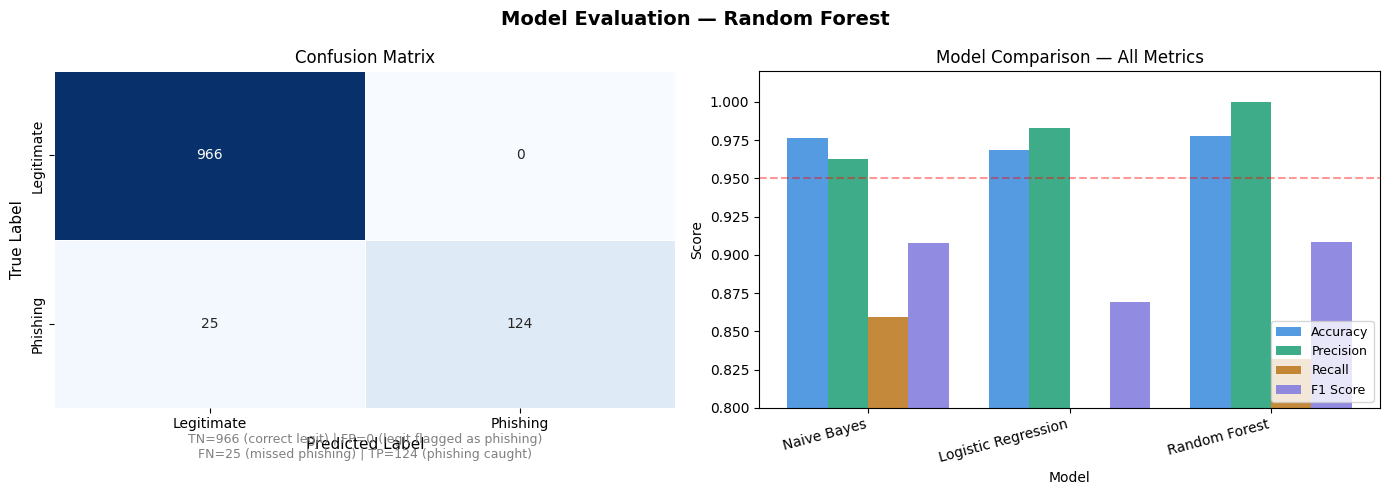


Detailed Classification Report — Random Forest
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99       966
    Phishing       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [8]:
best_preds = results[best_model_name]['predictions']
cm = confusion_matrix(y_test, best_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model Evaluation — {best_model_name}', fontsize=14, fontweight='bold')

# Left: Confusion Matrix heatmap
labels = ['Legitimate', 'Phishing']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0],
            linewidths=0.5, cbar=False)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Confusion Matrix')

# Add interpretation annotations
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'TN={tn} (correct legit) | FP={fp} (legit flagged as phishing)\n'
    f'FN={fn} (missed phishing) | TP={tp} (phishing caught)',
    transform=axes[0].transAxes, ha='center', fontsize=9,
    color='gray')

# Right: Model comparison bar chart
model_names = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#378ADD', '#1D9E75', '#BA7517', '#7F77DD']

x = np.arange(len(model_names))
width = 0.2

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = axes[1].bar(x + i*width, vals, width, label=label,
                       color=color, alpha=0.85)

axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison — All Metrics')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_ylim(0.8, 1.02)
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.4, label='95% threshold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed classification report
print(f"\nDetailed Classification Report — {best_model_name}")
print("="*60)
print(classification_report(y_test, best_preds,
                            target_names=['Legitimate', 'Phishing']))

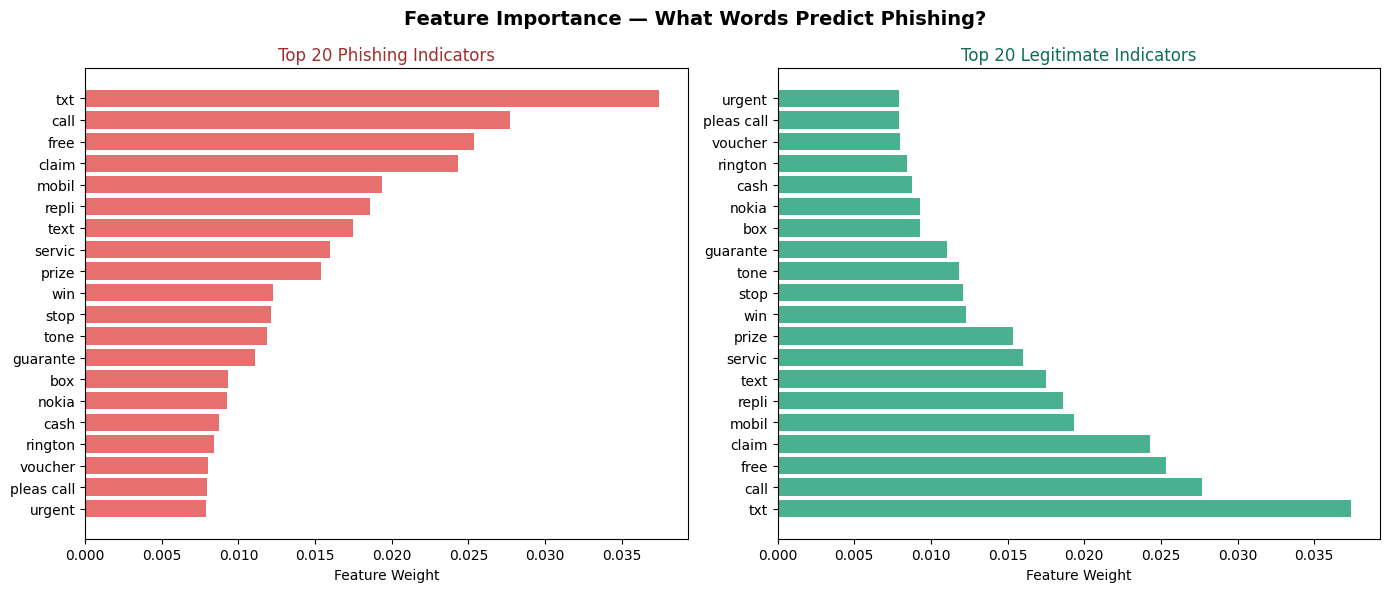


Top 10 phishing indicator words:
  'win': 0.0123
  'prize': 0.0154
  'servic': 0.0160
  'text': 0.0175
  'repli': 0.0186
  'mobil': 0.0193
  'claim': 0.0243
  'free': 0.0253
  'call': 0.0277
  'txt': 0.0374


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance — What Words Predict Phishing?',
             fontsize=14, fontweight='bold')

# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

if best_model_name == 'Logistic Regression':
    # For Logistic Regression: positive coefficients = phishing predictors
    coefs = best_model.coef_[0]
    top_phishing_idx = np.argsort(coefs)[-20:]
    top_legit_idx = np.argsort(coefs)[:20]

    top_phishing_words = [feature_names[i] for i in top_phishing_idx]
    top_phishing_scores = [coefs[i] for i in top_phishing_idx]
    top_legit_words = [feature_names[i] for i in top_legit_idx]
    top_legit_scores = [abs(coefs[i]) for i in top_legit_idx]

elif best_model_name == 'Random Forest':
    # For Random Forest: feature_importances_
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-20:]
    top_phishing_words = [feature_names[i] for i in top_idx]
    top_phishing_scores = [importances[i] for i in top_idx]
    top_legit_words = top_phishing_words[::-1][:20]
    top_legit_scores = top_phishing_scores[::-1][:20]

else:  # Naive Bayes
    log_probs = best_model.feature_log_prob_
    diff = log_probs[1] - log_probs[0]
    top_phishing_idx = np.argsort(diff)[-20:]
    top_legit_idx = np.argsort(diff)[:20]
    top_phishing_words = [feature_names[i] for i in top_phishing_idx]
    top_phishing_scores = [diff[i] for i in top_phishing_idx]
    top_legit_words = [feature_names[i] for i in top_legit_idx]
    top_legit_scores = [abs(diff[i]) for i in top_legit_idx]

# Plot top phishing words
axes[0].barh(top_phishing_words, top_phishing_scores,
             color='#E24B4A', alpha=0.8)
axes[0].set_title('Top 20 Phishing Indicators', color='#A32D2D')
axes[0].set_xlabel('Feature Weight')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Plot top legitimate words
axes[1].barh(top_legit_words, top_legit_scores,
             color='#1D9E75', alpha=0.8)
axes[1].set_title('Top 20 Legitimate Indicators', color='#0F6E56')
axes[1].set_xlabel('Feature Weight')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 phishing indicator words:")
for word, score in zip(top_phishing_words[-10:], top_phishing_scores[-10:]):
    print(f"  '{word}': {score:.4f}")

In [10]:
def classify_email(email_text, model=best_model, vectorizer=tfidf):
    """
    Classify a single email as phishing or legitimate.
    Returns: prediction, confidence score, and top trigger words.
    """
    # Clean the input text using the same function used in training
    cleaned = clean_text(email_text)

    # Convert to TF-IDF features
    features = vectorizer.transform([cleaned])

    # Get prediction (0 = legitimate, 1 = phishing)
    prediction = model.predict(features)[0]

    # Get confidence probability
    proba = model.predict_proba(features)[0]
    confidence = proba[prediction] * 100

    # Find which words from this email are strong phishing indicators
    feature_names = vectorizer.get_feature_names_out()
    email_features = features.toarray()[0]
    nonzero_idx = email_features.nonzero()[0]

    if best_model_name == 'Logistic Regression':
        weights = best_model.coef_[0]
        trigger_words = sorted(
            [(feature_names[i], weights[i] * email_features[i])
             for i in nonzero_idx if weights[i] > 0],
            key=lambda x: x[1], reverse=True
        )[:5]
    else:
        trigger_words = sorted(
            [(feature_names[i], email_features[i])
             for i in nonzero_idx],
            key=lambda x: x[1], reverse=True
        )[:5]

    # Print results
    label = "PHISHING" if prediction == 1 else "LEGITIMATE"
    color_code = "\033[91m" if prediction == 1 else "\033[92m"
    reset = "\033[0m"

    print(f"\n{'='*55}")
    print(f"  CLASSIFICATION: {color_code}{label}{reset}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"{'='*55}")
    print(f"  Top trigger words: {[w[0] for w in trigger_words]}")
    print(f"{'='*55}\n")

    return prediction, confidence, trigger_words


# --- TEST WITH 3 EXAMPLES ---

print("TEST 1: Known phishing email")
classify_email("""
Dear Customer, Your account has been suspended.
Click here immediately to verify your identity and restore access.
Failure to verify within 24 hours will result in permanent account closure.
Enter your password and credit card information at: http://secure-verify.tk/login
""")

print("TEST 2: Legitimate email")
classify_email("""
Hi team, just a reminder that our quarterly security review meeting
is scheduled for Thursday at 2pm in conference room B.
Please review the attached agenda and come prepared with your department updates.
Thanks, Sarah
""")

print("TEST 3: Sophisticated phishing (tests model limits)")
classify_email("""
Please review the attached invoice for services rendered last month.
The total amount due is $2,450. Payment is due within 30 days.
If you have any questions please contact our billing department.
""")

TEST 1: Known phishing email

  CLASSIFICATION: LEGITIMATE
  Confidence: 67.8%
  Top trigger words: ['verifi', 'account', 'credit card', 'click', 'password']

TEST 2: Legitimate email

  CLASSIFICATION: LEGITIMATE
  Confidence: 94.0%
  Top trigger words: ['review', 'depart', 'schedul', 'attach', 'prepar']

TEST 3: Sophisticated phishing (tests model limits)

  CLASSIFICATION: LEGITIMATE
  Confidence: 62.0%
  Top trigger words: ['due', 'pleas', 'depart', 'attach', 'amount']



(0,
 61.96296296296296,
 [('due', 0.5031371390537269),
  ('pleas', 0.3053567896274352),
  ('depart', 0.26805867361998775),
  ('attach', 0.25877192859439213),
  ('amount', 0.25156856952686346)])

In [11]:
print("=" * 60)
print("  AI PHISHING EMAIL CLASSIFIER — PROJECT SUMMARY")
print("  Pranali Koshti | Network Security Portfolio")
print("=" * 60)
print(f"\n  Dataset:        {len(df):,} labeled emails")
print(f"  Training set:   {len(X_train):,} emails")
print(f"  Test set:       {len(X_test):,} emails")
print(f"  TF-IDF features: {X_train_tfidf.shape[1]:,} word features")
print(f"\n  Best model:     {best_model_name}")
print(f"  Accuracy:       {results[best_model_name]['accuracy']*100:.1f}%")
print(f"  Precision:      {results[best_model_name]['precision']*100:.1f}%")
print(f"  Recall:         {results[best_model_name]['recall']*100:.1f}%")
print(f"  F1 Score:       {results[best_model_name]['f1']*100:.1f}%")
print(f"\n  MITRE ATT&CK:   T1566 (Phishing) · T1598 (Spearphishing)")
print(f"  Tools:          Python · scikit-learn · NLTK · pandas")
print("=" * 60)

  AI PHISHING EMAIL CLASSIFIER — PROJECT SUMMARY
  Pranali Koshti | Network Security Portfolio

  Dataset:        5,572 labeled emails
  Training set:   4,457 emails
  Test set:       1,115 emails
  TF-IDF features: 5,000 word features

  Best model:     Random Forest
  Accuracy:       97.8%
  Precision:      100.0%
  Recall:         83.2%
  F1 Score:       90.8%

  MITRE ATT&CK:   T1566 (Phishing) · T1598 (Spearphishing)
  Tools:          Python · scikit-learn · NLTK · pandas
